In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Load data
data = fetch_openml('credit-g', version=1, as_frame=True)
df = data.frame

print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (1000, 21)


In [4]:
# Encode target variable
df['target'] = df['class'].map({'good': 0, 'bad': 1})

In [5]:
# Convert numeric variables with few unique values to categorical
cols_to_categorical = ['installment_commitment', 'residence_since', 
                       'existing_credits', 'num_dependents']
# these are the variables we identified in EDA as having too few unique values
# to be treated as truly continuous numeric variables

for col in cols_to_categorical:
    df[col] = df[col].astype(str)
    
# Verify the conversion
print("Updated data types:")
print(df[cols_to_categorical].dtypes)

Updated data types:
installment_commitment    str
residence_since           str
existing_credits          str
num_dependents            str
dtype: object


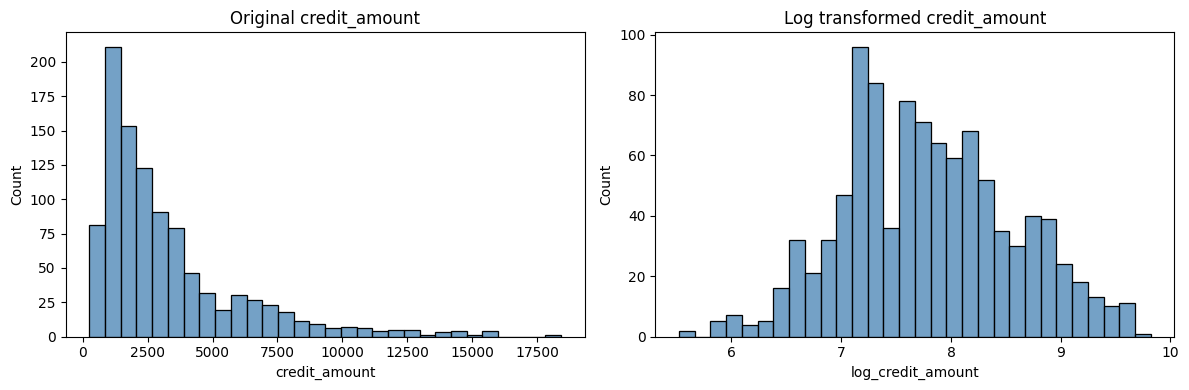

In [6]:
# Log transform credit_amount to reduce skewness and outlier impact
df['log_credit_amount'] = np.log(df['credit_amount'])

# Visualise the effect of the transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['credit_amount'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Original credit_amount')

sns.histplot(df['log_credit_amount'], bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Log transformed credit_amount')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
# import the train_test_split function from sklearn

# First define our feature set X and target y
X = df.drop(columns=['class', 'target', 'credit_amount'])
# X contains all our input features

y = df['target']
# y is our target variable — what we want to predict
# 0 = good, 1 = bad

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% of data goes to test set
    random_state=42,    # ensures reproducibility — same split every time you run it
    stratify=y          # ensures same class balance in both train and test sets
)


In [8]:
from optbinning import BinningProcess

# Define categorical variables - catch both 'object', 'category' and 'str' dtypes
categorical_variables = [col for col in X_train.columns 
                         if X_train[col].dtype == 'object' 
                         or X_train[col].dtype.name == 'category'
                         or X_train[col].dtype.name == 'str']
# dtype == 'object' — catches object columns
# dtype.name == 'category' — catches category columns
# dtype.name == 'str' — catches the columns we manually converted to string

print("Categorical variables:")
print(categorical_variables)
print(f"\nTotal categorical: {len(categorical_variables)}")

Categorical variables:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']

Total categorical: 17


In [9]:
print(X_train.dtypes)


checking_status           category
duration                     int64
credit_history            category
purpose                   category
savings_status            category
employment                category
installment_commitment         str
personal_status           category
other_parties             category
residence_since                str
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits               str
job                       category
num_dependents                 str
own_telephone             category
foreign_worker            category
log_credit_amount          float64
dtype: object


In [10]:
# Initialize and fit the BinningProcess
binning_process = BinningProcess(
    variable_names=list(X_train.columns),
    # list of all feature names

    categorical_variables=categorical_variables,
    # tells optbinning which variables are categorical

    max_n_bins=5,
    # maximum number of bins per variable
    # without overfitting to the training data
)

binning_process.fit(X_train, y_train)
# fit calculates the optimal weight of evidence (WoE) bins using the TRAINING data only
# y_train is needed so it can calculate default rates per bin

print("Binning process fitted successfully!")

Binning process fitted successfully!


In [11]:
# Transform training and test data using the fitted binning process
X_train_woe = binning_process.transform(X_train)
X_test_woe = binning_process.transform(X_test)


print("Training set after WoE transformation:")
print(X_train_woe.head())
print(f"\nShape: {X_train_woe.shape}")

Training set after WoE transformation:
     checking_status  duration  credit_history   purpose  savings_status  \
828        -0.765060 -0.572861       -0.103231  0.596155        0.762140   
997         1.142737  0.340927       -0.103231  0.453959       -0.290162   
148        -0.765060 -0.572861        0.703300 -0.129458       -0.290162   
735        -0.410580 -0.572861       -1.126883 -0.129458        0.762140   
130        -0.410580 -0.975131       -0.103231 -0.285829        0.762140   

     employment  installment_commitment  personal_status  other_parties  \
828    0.187599                0.063573         0.196255            0.0   
997    0.187599               -0.178443         0.196255            0.0   
148    0.113329                0.063573         0.196255            0.0   
735   -0.608406                0.063573        -0.260760            0.0   
130    0.400846                0.274845        -0.260760            0.0   

     residence_since  property_magnitude       age  o

In [12]:
binning_process.summary()

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,checking_status,categorical,OPTIMAL,True,4,0.616798,0.074059,0.398244,0.54645
1,duration,numerical,OPTIMAL,True,5,0.304412,0.035898,0.271964,0.503453
2,credit_history,categorical,OPTIMAL,True,4,0.262129,0.031641,0.243929,0.023248
3,purpose,categorical,OPTIMAL,True,5,0.152796,0.018828,0.205856,0.091281
4,savings_status,categorical,OPTIMAL,True,5,0.225283,0.027464,0.212128,0.008063
5,employment,categorical,OPTIMAL,True,5,0.125338,0.015488,0.178214,0.015511
6,installment_commitment,categorical,OPTIMAL,True,4,0.032373,0.004039,0.096637,0.007717
7,personal_status,categorical,OPTIMAL,True,4,0.057565,0.007165,0.121161,0.015684
8,other_parties,categorical,OPTIMAL,True,1,0.0,0.0,0,0.0
9,residence_since,categorical,OPTIMAL,True,4,0.00075,0.000094,0.014702,0.000001


In [13]:
cols_to_drop = ['other_parties', 'residence_since', 'num_dependents', 'foreign_worker']

X_train_woe = X_train_woe.drop(columns=cols_to_drop)
X_test_woe = X_test_woe.drop(columns=cols_to_drop)

print(f"Remaining features: {X_train_woe.shape[1]}")
print(f"Dropped: {cols_to_drop}")

Remaining features: 16
Dropped: ['other_parties', 'residence_since', 'num_dependents', 'foreign_worker']
